In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from scripts.predictor import Predictor

Importing plotly failed. Interactive plots will not work.


# Loading Data

In [3]:
df = pd.read_csv("../../data_processed/SG_nona.csv", parse_dates=["date"])

df

,date,new_confirmed,new_deceased,new_tested,cumulative_confirmed,cumulative_deceased,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,cumulative_persons_fully_vaccinated,...,search_trends_wheeze,search_trends_xeroderma,search_trends_xerostomia,search_trends_yawn,average_temperature_celsius,minimum_temperature_celsius,maximum_temperature_celsius,rainfall_mm,dew_point,relative_humidity
0,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.30,4.45,0.46,0.25,27.816667,25.400000,31.444444,0.406400,23.622222,78.160465
1,2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.31,4.33,0.44,0.19,27.483333,25.116667,30.522222,1.213556,24.072222,81.775103
2,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,4.40,0.40,0.21,27.627778,25.266667,31.172222,0.793750,24.255556,82.004853
3,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.29,4.78,0.42,0.21,27.200000,24.700000,30.883333,1.682750,23.800000,81.865993
4,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,4.44,0.41,0.24,27.744444,24.811111,31.872222,0.431800,23.477778,77.721261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2022-09-13,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
987,2022-09-14,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
988,2022-09-15,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
989,2022-09-16,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906


# Running Predictor

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.axes import Axes

In [39]:
def plot_scatter_on_ax(ax: Axes, df: pd.DataFrame, var_col: str, alg_type: str) -> None:
    ax.scatter(df["date"], df[f"{var_col}_{"yhat"}"], label = f"{alg_type}-{var_col}", s = 1, marker = ".")

def configure_axis(ax: Axes, df_before: pd.DataFrame) -> None:
    ax.axhline(0, color = "black", ls = "-", lw = 0.5)
    ax.axvline(df_before.date[0], color = "black", ls = "-", lw = 0.5)

    ax.axvline(df_before.iloc[-1]["date"], ls = "--", color = f"C{1}", lw = 1, label = "Prediction Starting")


    ax.tick_params(axis='x', labelrotation=-45, labelsize = 7)
    ax.tick_params(axis='y', labelrotation=-45, labelsize = 7)

    ax.legend()
    ax.grid(True)

In [40]:
def plot_multiple_data(df: pd.DataFrame, forecast: dict[str, pd.DataFrame], columns: list[str]) -> None:
    fig, axs = plt.subplots(len(columns), figsize = (9, 3 * len(columns)))




    for ax, col in zip(axs, columns):
        plot_scatter_on_ax(ax, forecast['prophet'], col, "prophet")
        plot_scatter_on_ax(ax, forecast["arima"], col, "arima")

    for ax in axs:
        configure_axis(ax=ax, df_before=df)

In [41]:
predictor = Predictor(df, 0, len(df) - 1, len(df))

In [42]:
predictor.fit(["new_confirmed", "search_trends_shyness"])

13:42:01 - cmdstanpy - INFO - Chain [1] start processing


13:42:01 - cmdstanpy - INFO - Chain [1] done processing


[Prophet] Fitting column: new_confirmed
[ARIMA]   Fitting column: new_confirmed


13:42:14 - cmdstanpy - INFO - Chain [1] start processing
13:42:14 - cmdstanpy - INFO - Chain [1] done processing


[Prophet] Fitting column: search_trends_shyness
[ARIMA]   Fitting column: search_trends_shyness
[OK] Fitting complete.


In [43]:
forecast = predictor.get_forecast()

In [44]:
forecast["prophet"]

,date,new_confirmed_yhat,new_confirmed_yhat_lower,new_confirmed_yhat_upper,search_trends_shyness_yhat,search_trends_shyness_yhat_lower,search_trends_shyness_yhat_upper
0,2022-09-18,6576.251478,550.515729,12473.625312,0.576924,0.449148,0.712302
1,2022-09-19,7658.084963,1879.096487,13399.688576,0.591587,0.454456,0.728862
2,2022-09-20,7295.899268,1590.011847,13029.340729,0.599009,0.466858,0.725608
3,2022-09-21,7232.945947,1287.949290,12914.181199,0.597566,0.458529,0.738313
4,2022-09-22,7249.538597,1603.774985,12903.109422,0.592869,0.465561,0.733020
...,...,...,...,...,...,...,...
986,2025-05-31,26047.351871,20361.581126,31740.436502,0.504889,0.368258,0.647667
987,2025-06-01,26026.492659,20354.573797,32174.436660,0.488795,0.358144,0.629918
988,2025-06-02,27095.900932,20928.122095,32786.852241,0.503462,0.363291,0.643123
989,2025-06-03,26721.230622,20631.635915,32882.315541,0.510888,0.376482,0.652861


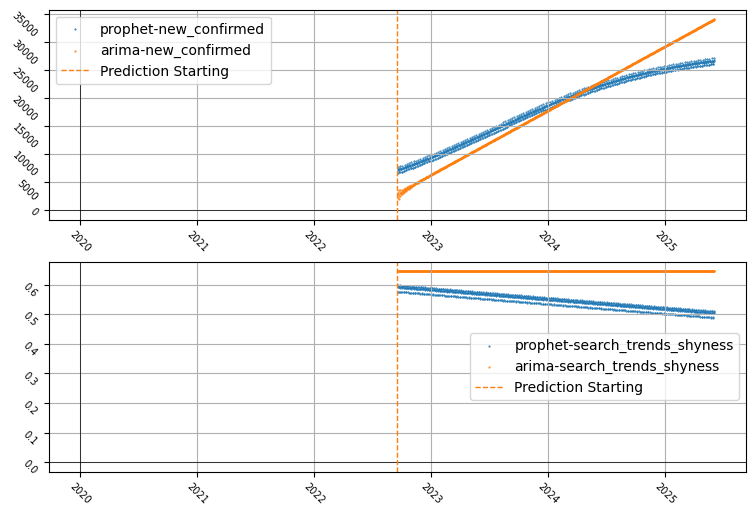

In [45]:
plot_multiple_data(df, forecast, ["new_confirmed", "search_trends_shyness"])